<a href="https://colab.research.google.com/github/kamrul017799/Cnn_23-50831-1_clothing_classification/blob/main/cnn.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Optional: architecture summary
!pip -q install torchinfo
from torchinfo import summary

In [ ]:
# =========================
# 2. SET SEED AND DEVICE
# =========================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# =========================
# 3. DOWNLOAD DATASET
# =========================

# Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d agrigorev/clothing-dataset-full
!unzip -q clothing-dataset-full.zip -d clothing_dataset

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/agrigorev/clothing-dataset-full
License(s): CC0-1.0
100% 6.50G/6.50G [00:56<00:00, 124MB/s]



In [ ]:
# =========================
# 4. LOAD CSV AND EXPLORE DATASET
# =========================

csv_path = "clothing_dataset/images.csv"
df = pd.read_csv(csv_path)

print(df.head())
print("\nColumns:", df.columns)
print("\nTotal samples before cleaning:", len(df))

                                  image  sender_id     label   kids
0  4285fab0-751a-4b74-8e9b-43af05deee22        124  Not sure  False
1  ea7b6656-3f84-4eb3-9099-23e623fc1018        148   T-Shirt  False
2  00627a3f-0477-401c-95eb-92642cbe078d         94  Not sure  False
3  ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa         43   T-Shirt  False
4  3b86d877-2b9e-4c8b-a6a2-1d87513309d0        189     Shoes  False

Columns: Index(['image', 'sender_id', 'label', 'kids'], dtype='object')

Total samples before cleaning: 5403


In [ ]:
# =========================
# 5. CLEAN LABELS AND KEEP  5 CLASSES
# =========================

# Remove uncertain labels
df = df[df["label"] != "Not sure"].reset_index(drop=True)

# Select top 5  classes
top_classes = df["label"].value_counts().head(5).index.tolist()

# Keep only those classes
df = df[df["label"].isin(top_classes)].reset_index(drop=True)

print("Selected top 5 classes:", top_classes)
print("\nFiltered dataset size:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Selected top 5 classes: ['T-Shirt', 'Longsleeve', 'Pants', 'Shoes', 'Shirt']

Filtered dataset size: 3211

Class distribution:
label
T-Shirt       1011
Longsleeve     699
Pants          692
Shoes          431
Shirt          378
Name: count, dtype: int64


In [ ]:
# =========================
# 6. TRAIN / VAL / TEST SPLIT
# =========================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Train samples: 2247
Validation samples: 482
Test samples: 482


In [ ]:
# =========================
# 7. CREATE IMAGEFOLDER-STYLE DIRECTORIES
# =========================

# Remove old split folder if it exists
shutil.rmtree("clothing_split", ignore_errors=True)

base_split_dir = Path("clothing_split")
for split in ["train", "val", "test"]:
    (base_split_dir / split).mkdir(parents=True, exist_ok=True)

img_dir = Path("clothing_dataset/images_compressed")

In [ ]:
# =========================
# 8. COPY IMAGES INTO CLASS FOLDERS
# =========================

def copy_images(df_split, split_name):
    """
    Copy images into PyTorch ImageFolder format:
    clothing_split/train/class_name/image.jpg
    """
    copied = 0
    for _, row in df_split.iterrows():
        label = row["label"]
        img_id = row["image"]

        src_path = img_dir / f"{img_id}.jpg"
        target_dir = base_split_dir / split_name / label
        target_dir.mkdir(parents=True, exist_ok=True)

        dst_path = target_dir / f"{img_id}.jpg"

        if src_path.exists():
            shutil.copy(src_path, dst_path)
            copied += 1

    print(f"{split_name}: copied {copied} images")

copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")

train: copied 2247 images
val: copied 482 images
test: copied 482 images


In [ ]:
# =========================
# 9. REMOVE CORRUPTED IMAGES
# =========================

def remove_bad_images(folder):
    """
    Remove corrupted or unreadable image files.
    """
    removed = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                os.remove(path)
                removed += 1
    print(f"Removed {removed} corrupted images from {folder}")

remove_bad_images("clothing_split/train")
remove_bad_images("clothing_split/val")
remove_bad_images("clothing_split/test")

Removed 0 corrupted images from clothing_split/train
Removed 0 corrupted images from clothing_split/val
Removed 0 corrupted images from clothing_split/test


In [ ]:
# =========================
# 10. DATA PREPROCESSING AND AUGMENTATION
# =========================

IMG_SIZE = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [ ]:
# =========================
# 11. LOAD DATASETS AND DATALOADERS
# =========================

train_dataset = ImageFolder("clothing_split/train", transform=train_transform)
val_dataset   = ImageFolder("clothing_split/val", transform=test_transform)
test_dataset  = ImageFolder("clothing_split/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['Longsleeve', 'Pants', 'Shirt', 'Shoes', 'T-Shirt']
Number of classes: 5
Train samples: 2247
Validation samples: 482
Test samples: 482


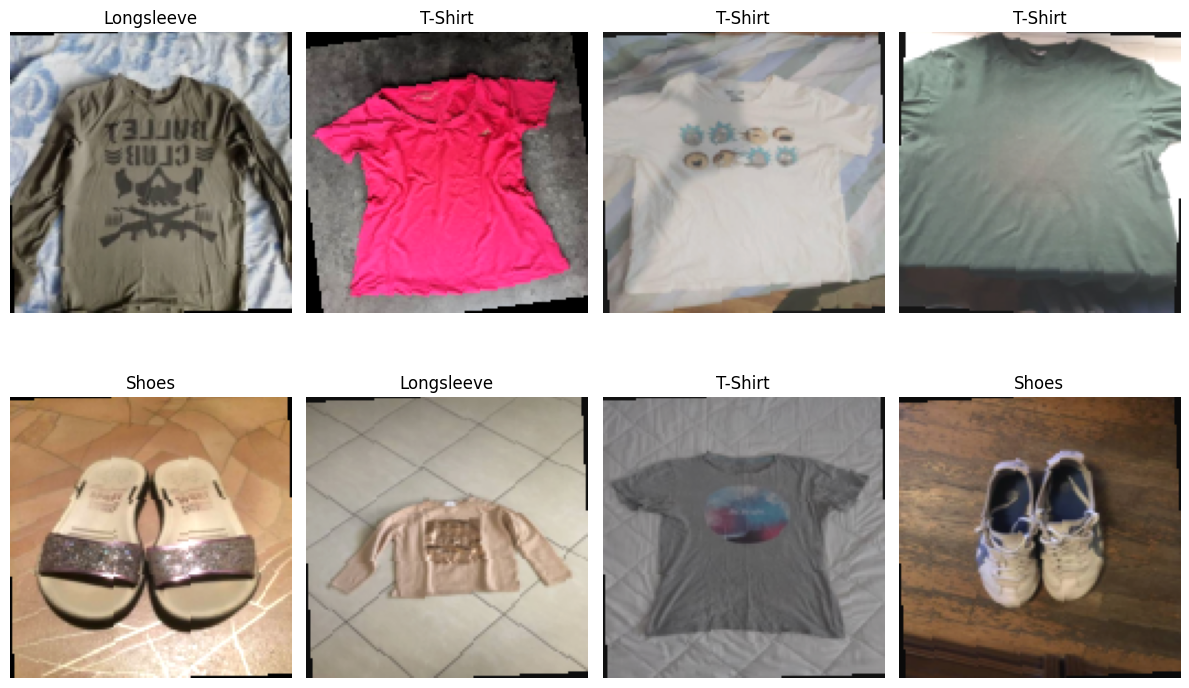

In [ ]:
# =========================
# 12. VISUALIZE SAMPLE IMAGES
# =========================

def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title(class_names[labels[i]])
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 13. DEFINE BASELINE CNN
# =========================

class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [ ]:
# =========================
# 14. DEFINE REGULARIZED CNN
# =========================

class RegularizedCNN(nn.Module):
    def __init__(self, num_classes):
        super(RegularizedCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [ ]:
# =========================
# 15. MODEL ARCHITECTURE SUMMARY
# =========================

baseline_model = BaselineCNN(num_classes).to(device)
regularized_model = RegularizedCNN(num_classes).to(device)

print("Baseline CNN Summary:")
summary(baseline_model, input_size=(1, 3, IMG_SIZE, IMG_SIZE))

print("\nRegularized CNN Summary:")
summary(regularized_model, input_size=(1, 3, IMG_SIZE, IMG_SIZE))

Baseline CNN Summary:

Regularized CNN Summary:


Layer (type:depth-idx)                   Output Shape              Param #
RegularizedCNN                           [1, 5]                    --
├─Sequential: 1-1                        [1, 128, 16, 16]          --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 128, 128]         64
│    └─ReLU: 2-3                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-4                    [1, 32, 64, 64]           --
│    └─Conv2d: 2-5                       [1, 64, 64, 64]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 64, 64]           128
│    └─ReLU: 2-7                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-8                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-9                       [1, 128, 32, 32]          73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 32, 32]          256
│    └─ReLU: 2-11                        [1, 128, 32, 32]          --
│   

In [ ]:
# =========================
# 16. TRAINING AND VALIDATION FUNCTIONS
# =========================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [ ]:
# =========================
# 17. FULL TRAINING FUNCTION
# =========================

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=15):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_model_wts = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = model.state_dict()

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)

    return model, history

In [ ]:
# =========================
# 18. TRAIN BASELINE MODEL
# =========================

baseline_model = BaselineCNN(num_classes).to(device)

criterion_base = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(baseline_model.parameters(), lr=0.001)
scheduler_base = StepLR(optimizer_base, step_size=5, gamma=0.5)

baseline_model, baseline_history = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_base,
    optimizer=optimizer_base,
    scheduler=scheduler_base,
    device=device,
    epochs=15
)

Epoch [1/15] | Train Loss: 1.3287 | Train Acc: 0.4575 | Val Loss: 0.9886 | Val Acc: 0.6245
Epoch [2/15] | Train Loss: 0.8825 | Train Acc: 0.6702 | Val Loss: 0.6792 | Val Acc: 0.7697
Epoch [3/15] | Train Loss: 0.6681 | Train Acc: 0.7588 | Val Loss: 0.5911 | Val Acc: 0.7739
Epoch [4/15] | Train Loss: 0.5767 | Train Acc: 0.7819 | Val Loss: 0.6221 | Val Acc: 0.7635
Epoch [5/15] | Train Loss: 0.4826 | Train Acc: 0.8269 | Val Loss: 0.5325 | Val Acc: 0.8071
Epoch [6/15] | Train Loss: 0.3788 | Train Acc: 0.8683 | Val Loss: 0.4950 | Val Acc: 0.8154
Epoch [7/15] | Train Loss: 0.3396 | Train Acc: 0.8758 | Val Loss: 0.5550 | Val Acc: 0.8050
Epoch [8/15] | Train Loss: 0.3017 | Train Acc: 0.8883 | Val Loss: 0.5014 | Val Acc: 0.8154
Epoch [9/15] | Train Loss: 0.2785 | Train Acc: 0.8990 | Val Loss: 0.5140 | Val Acc: 0.8257
Epoch [10/15] | Train Loss: 0.2586 | Train Acc: 0.9083 | Val Loss: 0.5161 | Val Acc: 0.8050
Epoch [11/15] | Train Loss: 0.2090 | Train Acc: 0.9341 | Val Loss: 0.5341 | Val Acc: 0.82

In [ ]:
# =========================
# 19. TRAIN REGULARIZED MODEL
# =========================

regularized_model = RegularizedCNN(num_classes).to(device)

criterion_reg = nn.CrossEntropyLoss()
optimizer_reg = optim.Adam(regularized_model.parameters(), lr=0.001)
scheduler_reg = StepLR(optimizer_reg, step_size=5, gamma=0.5)

regularized_model, regularized_history = train_model(
    model=regularized_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_reg,
    optimizer=optimizer_reg,
    scheduler=scheduler_reg,
    device=device,
    epochs=15
)

Epoch [1/15] | Train Loss: 3.4516 | Train Acc: 0.3605 | Val Loss: 1.1195 | Val Acc: 0.5394
Epoch [2/15] | Train Loss: 1.2071 | Train Acc: 0.5002 | Val Loss: 1.0103 | Val Acc: 0.6100
Epoch [3/15] | Train Loss: 1.0776 | Train Acc: 0.5585 | Val Loss: 0.8930 | Val Acc: 0.6743
Epoch [4/15] | Train Loss: 0.9838 | Train Acc: 0.6101 | Val Loss: 0.7658 | Val Acc: 0.7241
Epoch [5/15] | Train Loss: 0.9235 | Train Acc: 0.6182 | Val Loss: 0.7234 | Val Acc: 0.7220
Epoch [6/15] | Train Loss: 0.8250 | Train Acc: 0.6600 | Val Loss: 0.6918 | Val Acc: 0.7427
Epoch [7/15] | Train Loss: 0.7661 | Train Acc: 0.6978 | Val Loss: 0.6213 | Val Acc: 0.7531
Epoch [8/15] | Train Loss: 0.7662 | Train Acc: 0.6889 | Val Loss: 0.5918 | Val Acc: 0.7822
Epoch [9/15] | Train Loss: 0.7147 | Train Acc: 0.7116 | Val Loss: 0.6250 | Val Acc: 0.7635
Epoch [10/15] | Train Loss: 0.7215 | Train Acc: 0.7027 | Val Loss: 0.6065 | Val Acc: 0.7676
Epoch [11/15] | Train Loss: 0.6334 | Train Acc: 0.7437 | Val Loss: 0.5920 | Val Acc: 0.77

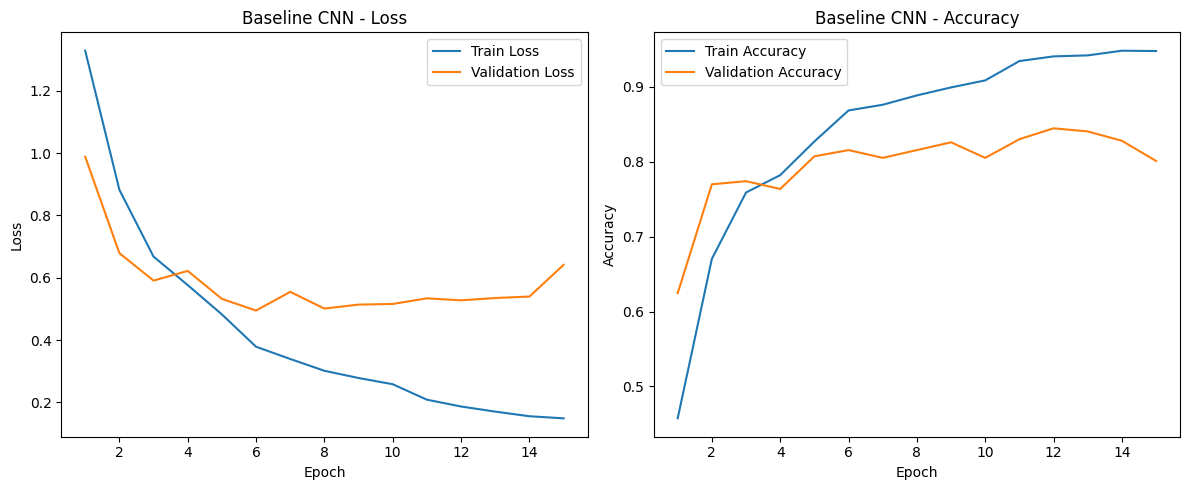

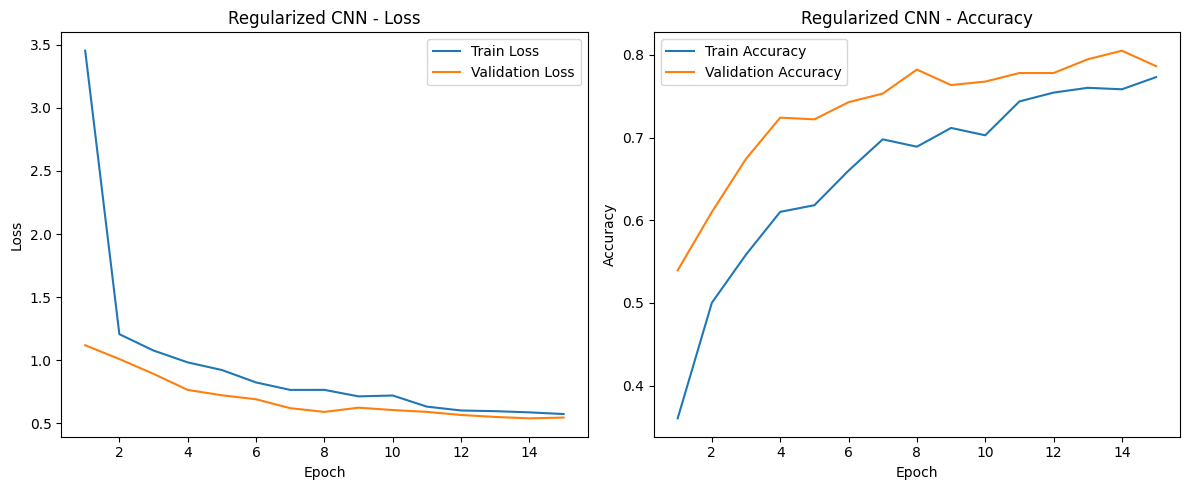

In [ ]:
# =========================
# 20. PLOT TRAINING CURVES
# =========================

def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")
plot_history(regularized_history, "Regularized CNN")

In [ ]:
# =========================
# 21. COMPARE MODELS
# =========================

best_baseline_val_acc = max(baseline_history["val_acc"])
best_regularized_val_acc = max(regularized_history["val_acc"])

print("Best Baseline Validation Accuracy:", best_baseline_val_acc)
print("Best Regularized Validation Accuracy:", best_regularized_val_acc)

if best_baseline_val_acc >= best_regularized_val_acc:
    best_model = baseline_model
    best_model_name = "Baseline CNN"
else:
    best_model = regularized_model
    best_model_name = "Regularized CNN"

print("Selected best model:", best_model_name)

Best Baseline Validation Accuracy: 0.8443983402489627
Best Regularized Validation Accuracy: 0.8049792531120332
Selected best model: Baseline CNN


In [ ]:
# =========================
# 22. EVALUATE ON TEST SET
# =========================

def evaluate_on_test(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return all_labels, all_preds, acc, precision, recall, f1

y_true, y_pred, test_acc, test_precision, test_recall, test_f1 = evaluate_on_test(
    best_model, test_loader, device
)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Precision:      {test_precision:.4f}")
print(f"Recall:         {test_recall:.4f}")
print(f"F1-score:       {test_f1:.4f}")

Test Accuracy:  0.8402
Precision:      0.8508
Recall:         0.8402
F1-score:       0.8413


In [ ]:
# =========================
# 23. CLASSIFICATION REPORT
# =========================

print(classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes,
    zero_division=0
))

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

              precision    recall  f1-score   support

  Longsleeve       0.83      0.67      0.74       105
       Pants       0.95      0.91      0.93       104
       Shirt       0.59      0.79      0.68        57
       Shoes       0.92      0.86      0.89        64
     T-Shirt       0.86      0.92      0.89       152

    accuracy                           0.84       482
   macro avg       0.83      0.83      0.83       482
weighted avg       0.85      0.84      0.84       482



,precision,recall,f1-score,support
Longsleeve,0.833333,0.666667,0.740741,105.000000
Pants,0.950000,0.913462,0.931373,104.000000
Shirt,0.592105,0.789474,0.676692,57.000000
Shoes,0.916667,0.859375,0.887097,64.000000
T-Shirt,0.864198,0.921053,0.891720,152.000000
accuracy,0.840249,0.840249,0.840249,0.840249
macro avg,0.831261,0.830006,0.825524,482.000000
weighted avg,0.850777,0.840249,0.841343,482.000000


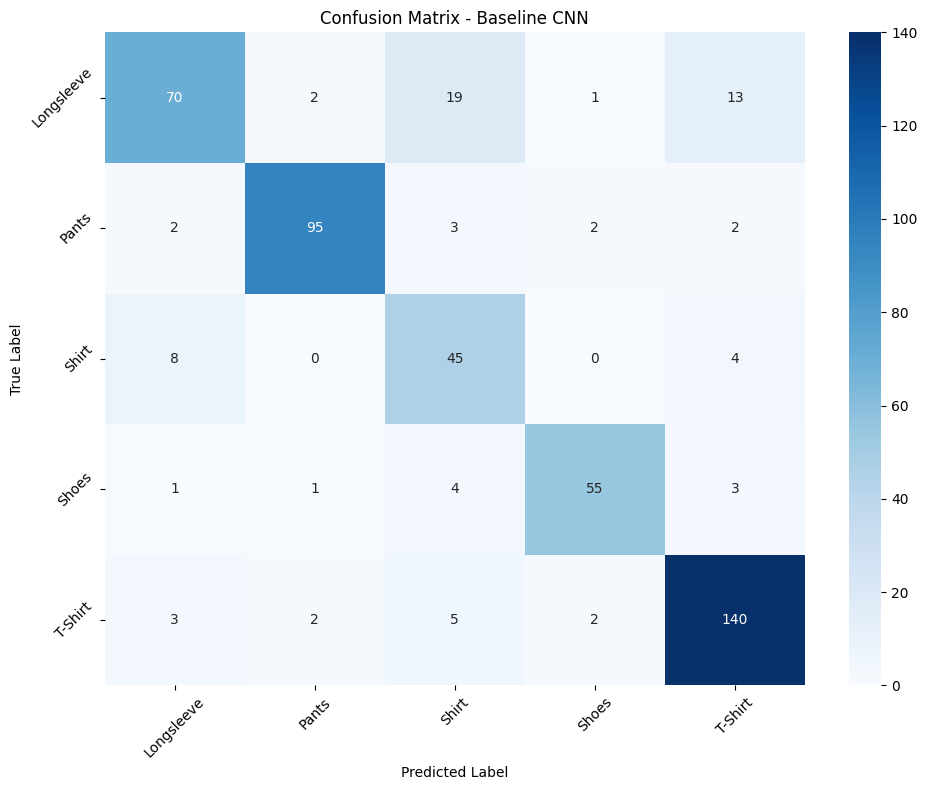

In [ ]:
# =========================
# 24. CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 25. BEST AND WORST PERFORMING CLASSES
# =========================

classwise_df = report_df.loc[test_dataset.classes, ["precision", "recall", "f1-score", "support"]]
classwise_df = classwise_df.sort_values(by="f1-score", ascending=False)

print("Best Performing Classes:")
print(classwise_df.head(3))

print("\nWorst Performing Classes:")
print(classwise_df.tail(3))

Best Performing Classes:
         precision    recall  f1-score  support
Pants     0.950000  0.913462  0.931373    104.0
T-Shirt   0.864198  0.921053  0.891720    152.0
Shoes     0.916667  0.859375  0.887097     64.0

Worst Performing Classes:
            precision    recall  f1-score  support
Shoes        0.916667  0.859375  0.887097     64.0
Longsleeve   0.833333  0.666667  0.740741    105.0
Shirt        0.592105  0.789474  0.676692     57.0


In [ ]:
# ============================================================
# SAVE TRAINED MODEL
# ============================================================

import torch

# Save model weights
torch.save(best_model.state_dict(), "best_clothing_cnn(23-50831-1).pth")

print("Model saved successfully as best_clothing_cnn_(23-50831-1).pth")

Model saved successfully as best_clothing_cnn_(23-50831-1).pth


In [ ]:
# ============================================================
# SAVE CLASS NAMES
# ============================================================

class_names = test_dataset.classes

with open("class_names.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")

print("Class names saved successfully.")

Class names saved successfully.


## Model Comparison

Two CNN models were implemented and compared:

1. **Baseline CNN**
2. **Regularized CNN with Batch Normalization and Dropout**

The baseline CNN is a simple custom architecture with three convolutional blocks followed by two fully connected layers. The regularized CNN uses Batch Normalization after each convolution layer and Dropout before the final classification layer.

The purpose of this comparison is to analyze whether regularization improves generalization performance on the selected 5 clothing classes.

## Results and Discussion

The models were evaluated using accuracy, precision, recall, and F1 score on the test set. A confusion matrix was also generated to analyze class wise performance.

The best performing classes generally had clearer visual characteristics and more samples, while weaker classes had higher visual similarity with other classes. The confusion matrix helped identify which classes were most often misclassified.

This experiment shows that reducing the dataset to the  5 classes simplifies the classification task and can improve performance compared to using many low frequency classes.

## Conclusion

In this assignment, a custom CNN was developed for image classification on a clothing dataset. After cleaning the dataset and selecting the  5 most frequent classes, two CNN models were trained and compared.

The project successfully covered:
- dataset preprocessing
- train/validation/test splitting
- custom CNN design
- regularization comparison
- model training with optimizer and scheduler
- test evaluation using multiple metrics
- confusion matrix visualization
- best and worst class analysis
- saving trained model weights

